In [10]:
import os
import time
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

# For Problem 15
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002B785EE04C0>
Traceback (most recent call last):
  File "c:\Users\72919\.conda\envs\pytorch_env\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\Users\72919\.conda\envs\pytorch_env\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


1. Write a Python function to sum all the numbers in a list.

In [2]:
def sum_list(numbers):
    total = 0
    for x in numbers:
        total += x
    return total

nums = [8, 2, 3, 0, 7]
print("sum:", sum_list(nums))
# 这题是要用np.sum()吗？
print("np.sum(nums):", np.sum(nums))


sum: 20
np.sum(nums): 20


2. Write a Python function that takes a list and returns a new list with unique elements of the first list.
e.g.,
Input:[1, 2, 3, 3, 3, 3, 4, 5].
Output: [1, 2, 3, 4, 5].

In [3]:
def unique_elements(items):
    seen = set()
    result = []
    for x in items:
        if x not in seen:
            seen.add(x)
            result.append(x)
    return result

arr = [1, 2, 3, 3, 3, 3, 4, 5]
print("unique:", unique_elements(arr))
print("np.unique:",np.unique(arr))


unique: [1, 2, 3, 4, 5]
np.unique: [1 2 3 4 5]


3. Write a Python function that checks whether a passed string is palindrome or not. A palindrome is a word,
phrase, or sequence that reads the same backward as forward. For example, both “madam” and “nurses run”
are palindromes.

In [5]:
def is_palindrome(text):
    cleaned = "".join(ch.lower() for ch in text if ch.isalnum())
    return cleaned == cleaned[::-1]

print("madam ->", is_palindrome("madam"))
print("nurses run ->", is_palindrome("nurses run"))
print("hello ->", is_palindrome("hello"))


madam -> True
nurses run -> True
hello -> False


4. Write a NumPy program to find the real and imaginary parts of an array of complex numbers.
e.g.,
Input: array [ 1.00000000+0.j 0.70710678+0.70710678j]
Output: array [[1, 0], [0.70710678, 0.70710678]]

In [7]:
def real_imag_parts(z):
    z = np.asarray(z, dtype=np.complex128)
    return np.column_stack((z.real, z.imag))

z = np.array([1.0 + 0.0j, 0.70710678 + 0.70710678j])
print(real_imag_parts(z))


[[1.         0.        ]
 [0.70710678 0.70710678]]


5. Write a Python program to add two binary numbers.
e.g.,
Input : (’11’, ’1’)
Output : 100

In [8]:
def add_binary(a, b):
    i, j = len(a) - 1, len(b) - 1
    carry = 0
    out = []

    while i >= 0 or j >= 0 or carry:
        bit_a = ord(a[i]) - ord("0") if i >= 0 else 0
        bit_b = ord(b[j]) - ord("0") if j >= 0 else 0
        s = bit_a + bit_b + carry
        out.append(str(s % 2))
        carry = s // 2
        i -= 1
        j -= 1

    return "".join(reversed(out))

print(add_binary("11", "1"))


100


6. You are given two non-empty linked lists representing two non-negative integers. The digits are stored in reverse order and each of their nodes contain a single digit. Add the two numbers and return it as a linked list. You may assume the two numbers do not contain any leading zero, except the number 0 itself.  

e.g.,  
Input: (2 -> 4 -> 3) + (5 -> 6 -> 4)  
Output: 7 -> 0 -> 8  
Explanation: 342 + 465 = 807.  

Linked list is defined as follow:

Definition for singly-linked list.
```python
class ListNode:
    def __init__(self, x):
        self.val = x
        self.next = None

In [9]:
class ListNode:
    def __init__(self, x):
        self.val = x
        self.next = None


def add_two_numbers(l1, l2):
    dummy = ListNode(0)
    cur = dummy
    carry = 0

    while l1 is not None or l2 is not None or carry:
        x = l1.val if l1 is not None else 0
        y = l2.val if l2 is not None else 0
        s = x + y + carry

        carry = s // 10
        cur.next = ListNode(s % 10)
        cur = cur.next

        if l1 is not None:
            l1 = l1.next
        if l2 is not None:
            l2 = l2.next

    return dummy.next


def build_list(values):
    dummy = ListNode(0)
    cur = dummy
    for v in values:
        cur.next = ListNode(v)
        cur = cur.next
    return dummy.next


def to_pylist(head):
    out = []
    while head is not None:
        out.append(head.val)
        head = head.next
    return out

l1 = build_list([2, 4, 3])
l2 = build_list([5, 6, 4])
ans = add_two_numbers(l1, l2)
print(to_pylist(ans))  # [7, 0, 8]


[7, 0, 8]


7. Implement bubble sort

In [10]:
def bubble_sort(arr):
    a = arr[:]
    n = len(a)
    for i in range(n):
        swapped = False
        for j in range(0, n - 1 - i):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True
        if not swapped:
            break
    return a

print(bubble_sort([64, 34, 25, 12, 22, 11, 90]))


[11, 12, 22, 25, 34, 64, 90]


8. Implement merge sort

In [11]:
def merge(left, right):
    merged = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged


def merge_sort(arr):
    if len(arr) <= 1:
        return arr[:]
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)

print(merge_sort([38, 27, 43, 3, 9, 82, 10]))


[3, 9, 10, 27, 38, 43, 82]


9. Implement quick sort

In [12]:
def quick_sort(arr):
    if len(arr) <= 1:
        return arr[:]
    pivot = arr[len(arr) // 2]
    less = [x for x in arr if x < pivot]
    equal = [x for x in arr if x == pivot]
    greater = [x for x in arr if x > pivot]
    return quick_sort(less) + equal + quick_sort(greater)

print(quick_sort([10, 7, 8, 9, 1, 5]))


[1, 5, 7, 8, 9, 10]


10. Implement shell sort

In [13]:
def shell_sort(arr):
    a = arr[:]
    n = len(a)
    gap = n // 2

    while gap > 0:
        for i in range(gap, n):
            temp = a[i]
            j = i
            while j >= gap and a[j - gap] > temp:
                a[j] = a[j - gap]
                j -= gap
            a[j] = temp
        gap //= 2

    return a

print(shell_sort([12, 34, 54, 2, 3]))


[2, 3, 12, 34, 54]


11. Implement linear regression model and use autograd to optimize it by Pytorch.

In [ ]:
torch.manual_seed(0)

n_samples = 200
x = torch.randn(n_samples, 1)
true_w = torch.tensor([[2.5]])
true_b = torch.tensor([0.7])
y = x @ true_w + true_b + 0.2 * torch.randn(n_samples, 1)

w = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1
epochs = 300

for epoch in range(epochs):
    y_pred = x @ w + b
    loss = ((y_pred - y) ** 2).mean()

    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:3d} | loss={loss.item():.6f}")

print("learned w:", w.item(), "learned b:", b.item())


epoch 100 | loss=0.044977
epoch 200 | loss=0.044977
epoch 300 | loss=0.044977
learned w: 2.4845588207244873 learned b: 0.6911712884902954


12. Implement logistic regression model and use autograd to optimize it by Pytorch.

In [15]:
torch.manual_seed(0)

n = 400
x = torch.randn(n, 2)
true_w = torch.tensor([[2.0], [-1.5]])
true_b = torch.tensor([0.3])
logits = x @ true_w + true_b
probs = torch.sigmoid(logits)
y = (probs > 0.5).float().view(-1, 1)

w = torch.zeros(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.5
epochs = 300
eps = 1e-8

for epoch in range(epochs):
    logits_hat = x @ w + b
    p = torch.sigmoid(logits_hat)
    loss = -(y * torch.log(p + eps) + (1 - y) * torch.log(1 - p + eps)).mean()

    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 100 == 0:
        pred = (p >= 0.5).float()
        acc = (pred == y).float().mean().item()
        print(f"epoch {epoch+1:3d} | loss={loss.item():.6f} | acc={acc:.4f}")


epoch 100 | loss=0.161137 | acc=0.9875
epoch 200 | loss=0.124913 | acc=0.9875
epoch 300 | loss=0.108035 | acc=0.9875


13. Implement linear SVM model for binary classification task and use autograd to optimize it by Pytorch.
Hint: you may use the loss of $\sum max [0, 1 − y (wx + b)]$

In [12]:
# Linear SVM (binary) with hinge loss and autograd
torch.manual_seed(0)

n = 300
x = torch.randn(n, 2)
raw = x[:, 0] - 0.8 * x[:, 1] + 0.2
y = torch.where(raw > 0, torch.tensor(1.0), torch.tensor(-1.0)).view(-1, 1)

w = torch.zeros(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1
epochs = 300

for epoch in range(epochs):
    scores = x @ w + b
    hinge = torch.clamp(1 - y * scores, min=0)
    loss = hinge.mean()

    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 100 == 0:
        pred = torch.where(scores >= 0, torch.tensor(1.0), torch.tensor(-1.0))
        acc = (pred == y).float().mean().item()
        print(f"epoch {epoch+1:3d} | loss={loss.item():.6f} | acc={acc:.4f}")


epoch 100 | loss=0.190742 | acc=0.9867
epoch 200 | loss=0.148032 | acc=0.9900
epoch 300 | loss=0.130061 | acc=0.9900


14. Add a Frobenius norm penalty for the weight $w$ in your SVM model by two different ways: (1) use a pytorch function to calculate the norm; (2) implement the code by yourself.  

Hint: Frobenius norm of a matrix $A$ is $||A||_F = \left(\sum_{i=1}^n \sum_{j=1}^m |a_{ij}|^2\right)^\frac{1}{2}$.

In [13]:
# Add Frobenius norm penalty for SVM in two ways
def train_svm_with_reg(use_torch_norm=True, lam=0.01, epochs=200, lr=0.1):
    w = torch.zeros(2, 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)

    for _ in range(epochs):
        scores = x @ w + b
        hinge = torch.clamp(1 - y * scores, min=0).mean()

        if use_torch_norm:
            reg = torch.norm(w, p="fro")
        else:
            reg = torch.sqrt(torch.sum(w * w))

        loss = hinge + lam * reg

        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()

    with torch.no_grad():
        pred = torch.where((x @ w + b) >= 0, torch.tensor(1.0), torch.tensor(-1.0))
        acc = (pred == y).float().mean().item()
    return w.detach(), b.detach(), acc

w1, b1, acc1 = train_svm_with_reg(use_torch_norm=True)
w2, b2, acc2 = train_svm_with_reg(use_torch_norm=False)

print("Method 1 (torch.norm) acc:", acc1)
print("Method 2 (manual norm) acc:", acc2)
print("w difference:", torch.norm(w1 - w2).item())


Method 1 (torch.norm) acc: 0.9833333492279053
Method 2 (manual norm) acc: 0.4300000071525574
w difference: nan


15. Learn how to use linear regression<sup>[1]</sup>, logistic regression<sup>[2]</sup>, and SVM<sup>[3]</sup> by scikit-learn.

In [ ]:
np.random.seed(0)

X_lr = np.random.randn(300, 3)
coef = np.array([1.5, -2.0, 0.7])
y_lr = X_lr @ coef + 0.5 + 0.2 * np.random.randn(300)
X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
print("LinearRegression MSE:", mean_squared_error(y_test, y_pred))

X_log = np.random.randn(400, 2)
logit = 2 * X_log[:, 0] - 1.2 * X_log[:, 1] + 0.3
y_log = (1 / (1 + np.exp(-logit)) > 0.5).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("LogisticRegression ACC:", accuracy_score(y_test, y_pred))

X_svm = np.random.randn(400, 2)
y_svm = (X_svm[:, 0] - X_svm[:, 1] > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_svm, y_svm, test_size=0.2, random_state=42)
svm = SVC(kernel="linear")
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("Linear SVM ACC:", accuracy_score(y_test, y_pred))


LinearRegression MSE: 0.034306002558118553
LogisticRegression ACC: 0.9625
Linear SVM ACC: 1.0


16. Download CIFAR-10 dataset<sup>[4]</sup> and visualize some of its images.

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data


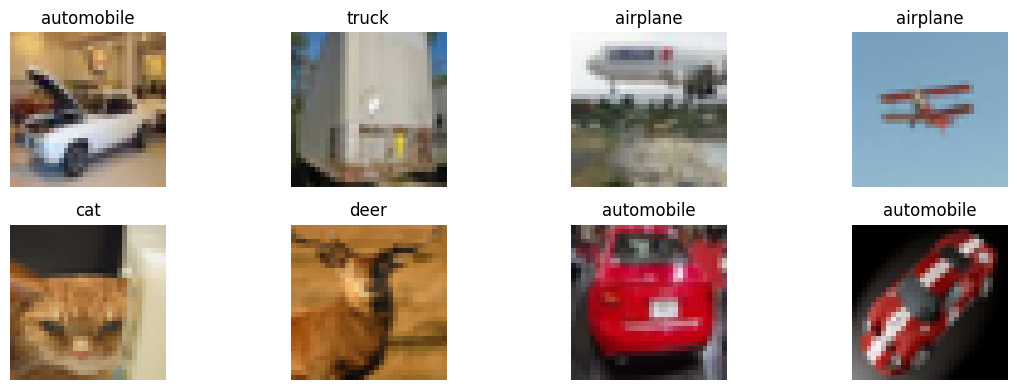

In [ ]:
import torchvision

root = "./data"
train_set = torchvision.datasets.CIFAR10(root=root, train=True, download=True)

class_names = train_set.classes
indices = random.sample(range(len(train_set)), 8)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices, 1):
    img, label = train_set[idx]
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")
plt.tight_layout()
plt.show()


17. Write a dataset class for loading CIFAR-10. Make sure it could be transferred to Pytorch `Dataloader`. The class should meet the following requirements: (1) Inherit pytorch's `DataSet` class; (2) Load the image file and save in proper way; (3) Override `__getitem__` and `__len__` methods.  

Hint: If you find this part a little hard, check the official code<sup>[5]</sup> and make sure you understand each part.

In [ ]:
import os
import pickle
import numpy as np
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

class MyCIFAR10Dataset(Dataset):
    def __init__(self, root, train=True, transform=None):
        self.root = root
        self.train = train
        self.transform = transform
        self.data = []
        self.targets = []

        base = os.path.join(root, "cifar-10-batches-py")
        if train:
            files = [f"data_batch_{i}" for i in range(1, 6)]
        else:
            files = ["test_batch"]

        for fn in files:
            path = os.path.join(base, fn)
            with open(path, "rb") as f:
                entry = pickle.load(f, encoding="latin1")
            self.data.append(entry["data"])
            self.targets.extend(entry["labels"])

        self.data = np.vstack(self.data).reshape(-1, 3, 32, 32)
        self.data = self.data.transpose(0, 2, 3, 1)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        img = self.data[index]
        label = self.targets[index]
        img = Image.fromarray(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

transform = T.ToTensor()
my_train = MyCIFAR10Dataset(root="./data", train=True, transform=transform)
loader = DataLoader(my_train, batch_size=4, shuffle=True)
imgs, labels = next(iter(loader))
print("batch image shape:", imgs.shape)
print("batch labels:", labels)


batch image shape: torch.Size([4, 3, 32, 32])
batch labels: tensor([7, 1, 7, 3])


18. Read<sup>[6]</sup> and learn how to use `torchvision.transforms` to transform images.

In [7]:
import torchvision
import torchvision.transforms as T

transform_pipeline = T.Compose(
    [
        T.Resize((40, 40)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomCrop((32, 32)),
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
)

raw_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=False)
raw_img, raw_label = raw_dataset[0]

tensor_img = transform_pipeline(raw_img)
print("original size:", raw_img.size)
print("transformed tensor shape:", tensor_img.shape)
print("label:", raw_label)


original size: (32, 32)
transformed tensor shape: torch.Size([3, 32, 32])
label: 6


19. Run one epoch for loading CIFAR-10 with Pytorch `Dataloader` and test the loading time of different `batch_size` (1, 4, 64, 1024), different `num_workers` (0,1,4,16), and whether use `pin_memory` or not.

In [ ]:
import time
import itertools
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

def time_one_epoch(dataset, batch_size, num_workers, pin_memory, max_batches=50):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False 
    )
    
    start = time.perf_counter()
    n_batches = 0
    n_samples = 0
    
    for imgs, labels in loader:
        n_batches += 1
        n_samples += imgs.size(0)
        # 满足50个batch即退出
        if max_batches is not None and n_batches >= max_batches:
            break
            
    elapsed = time.perf_counter() - start
    return elapsed, n_batches, n_samples

if __name__ == '__main__':
    # 缩小数据集以加速测试。设置 5120 是为了让 batch_size=1024 时也能完整跑出 5 个 batch
    subset_size = 5120 
    max_batches = 50   # 题目要求的：batch数量限制在50
    
    print("Loading Dataset...")
    full_dataset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=T.ToTensor()
    )
    benchmark_dataset = Subset(full_dataset, range(subset_size))
    
    print(f"Dataset ready. Samples={len(benchmark_dataset)}, Max_batches_per_test={max_batches}\n")

    # 参数列表
    batch_sizes = [1, 4, 64, 1024]
    num_workers_list = [0, 1, 4, 16]
    pin_memory_list = [False, True]

    results = []

    for bs, nw, pm in itertools.product(batch_sizes, num_workers_list, pin_memory_list):
        try:
            elapsed, n_batches, n_samples = time_one_epoch(
                benchmark_dataset, bs, nw, pm, max_batches=max_batches
            )
            results.append((bs, nw, pm, elapsed, n_batches, n_samples))
            print(f"BS={bs:<4d} | Workers={nw:<2d} | PinMem={str(pm):<5} | "
                  f"Time={elapsed:.3f}s | Batches={n_batches} | Samples={n_samples}")
        except Exception as e:
            print(f"BS={bs:<4d} | Workers={nw:<2d} | PinMem={str(pm):<5} | FAILED: {e}")

    # 打印最快的前 5 个配置
    ok = [r for r in results if r[3] is not None]
    ok = sorted(ok, key=lambda x: x[3])
    print("\n--- Top 5 Fastest Settings ---")
    for r in ok[:5]:
        print(f"BS={r[0]:<4d} | Workers={r[1]:<2d} | PinMem={str(r[2]):<5} | Time={r[3]:.3f}s")

Loading Dataset...
Files already downloaded and verified
Dataset ready. Samples=5120, Max_batches_per_test=50

BS=1    | Workers=0  | PinMem=False | Time=0.009s | Batches=50 | Samples=50
BS=1    | Workers=0  | PinMem=True  | Time=0.006s | Batches=50 | Samples=50
BS=1    | Workers=1  | PinMem=False | Time=3.357s | Batches=50 | Samples=50
BS=1    | Workers=1  | PinMem=True  | Time=3.360s | Batches=50 | Samples=50
BS=1    | Workers=4  | PinMem=False | Time=12.089s | Batches=50 | Samples=50
BS=1    | Workers=4  | PinMem=True  | Time=14.037s | Batches=50 | Samples=50
BS=1    | Workers=16 | PinMem=False | Time=53.393s | Batches=50 | Samples=50
BS=1    | Workers=16 | PinMem=True  | Time=58.746s | Batches=50 | Samples=50
BS=4    | Workers=0  | PinMem=False | Time=0.034s | Batches=50 | Samples=200
BS=4    | Workers=0  | PinMem=True  | Time=0.031s | Batches=50 | Samples=200
BS=4    | Workers=1  | PinMem=False | Time=5.303s | Batches=50 | Samples=200
BS=4    | Workers=1  | PinMem=True  | Time=5.9

20.  Calculate the mean and std of CIFAR-10’ training set within each RGB channel

In [3]:
import numpy as np
import torchvision

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=False)
data = train_set.data.astype(np.float32) / 255.0  # shape: (50000, 32, 32, 3)

channel_mean = data.mean(axis=(0, 1, 2))
channel_std = data.std(axis=(0, 1, 2))

print("CIFAR-10 train channel mean (R, G, B):", channel_mean)
print("CIFAR-10 train channel std  (R, G, B):", channel_std)


CIFAR-10 train channel mean (R, G, B): [0.4914009  0.48215896 0.4465308 ]
CIFAR-10 train channel std  (R, G, B): [0.24703279 0.24348423 0.26158753]
